# Sprint 1 — Analisi Preliminare

> 📊 **Dataset**: UCI Machine Learning Repository — *Predict Students'
> Dropout and Academic Success* (4.424 studenti, 36 feature + 1 target).
> 🔗 https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

## Obiettivo del notebook

Questo notebook copre le **User Story di Sprint 1** del progetto di
predizione del dropout universitario. Lo scopo dello Sprint è preparare
il dataset prima dell'analisi esplorativa: caricamento, definizione del
target binario, normalizzazione dei nomi colonna, gestione di duplicati
e missing values, prime statistiche descrittive.

In altre parole: alla fine di questo notebook avremo un DataFrame pulito,
ben tipizzato e con un target binario `Dropout` / `Graduate`, pronto per
le US di Sprint 2 (analisi esplorativa) e Sprint 3 (modeling).

## Indice e responsabilità

| # | User Story | Responsabile |
|---|---|---|
| 1 | [US-01 · Caricamento e prima ispezione del dataset](#us-01) | Youssra |
| 2 | [US-02 · Rimozione "Enrolled" e definizione del target](#us-02) | Jessica |
| 3 | [US-03 · Rinomina delle variabili](#us-03) | Youssra |
| 4 | [US-04 · Controllo dei duplicati](#us-04) | Jessica |
| 5 | [US-05 · Analisi dei missing values](#us-05) | Youssra |
| 6 | [US-06 · Analisi descrittiva delle variabili numeriche](#us-06) | Jessica |

📦 [Export del dataset processato](#export)

## Note sull'esecuzione

- **Path del dataset**: `../data/raw/data.csv` (relativo alla cartella
  `notebooks/`). Il file usa `;` come separatore, non la virgola.
- **Esecuzione lineare**: le celle vanno eseguite in ordine, dall'alto
  verso il basso. Ogni US assume che le precedenti siano state eseguite.
- **Output dei grafici**: salvati in `outputs/figures/` con naming
  `usXX_<descrizione-kebab-case>.png`.
- **Funzioni riutilizzabili**: importate da `src/` quando applicabile.

---

## Setup

Dipendenze del notebook. Le librerie sono elencate in `requirements.txt`
e vanno installate nel virtual env del progetto prima di eseguire le
celle successive.

In [1]:
# Standard library
import os
import sys
from pathlib import Path

# Aggiungi la root del progetto al path Python, così che `src` sia importabile
sys.path.insert(0, os.path.abspath('..'))

# Third-party
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Local
from src.preprocessing import rename_columns
from src.preprocessing import analyze_missing_values

---

## US-01 · Caricamento e Prima Ispezione del Dataset <a id="us-01"></a>

**Responsabile**: Youssra Zarouky

### Obiettivo
In questa sezione carichiamo il dataset e verifichiamo che sia quello corretto 
prima di fare qualsiasi analisi.

In [2]:
df = pd.read_csv('../data/raw/data.csv', sep=';')

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Verifica dimensioni e tipi di dato

Controlliamo che il numero di righe e colonne corrisponda a quello atteso dalla documentazione UCI, 
e che i tipi di dato siano corretti.

In [3]:
# Il dataset dovrebbe avere 4424 righe e 37 colonne (36 feature + 1 target) come da documentazione UCI
print("Righe e colonne:", df.shape)
print()
print(df.dtypes)
# La maggior parte delle variabili sono numeriche (int64, float64)
# Alcune variabili categoriche (es. stato civile, corso) sono codificate come int
# Solo Target è testuale (object): contiene Dropout, Graduate, Enrolled

Righe e colonne: (4424, 37)

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                    

In [4]:
df.tail()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate
4423,1,10,1,9773,1,1,152.0,22,38,37,...,0,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate


---

## US-02 · Rimozione "Enrolled" e Definizione del Target <a id="us-02"></a>

**Responsabile**: Jessica M Pucci

### Obiettivo
Filtrare il dataset per tenere solo gli studenti con outcome accademico
definitivo (`Dropout` o `Graduate`), escludendo gli studenti ancora iscritti
(`Enrolled`) il cui percorso non è ancora concluso. Codificare il target
in formato numerico per le fasi successive di modeling.

### Approccio
1. **Snapshot della distribuzione iniziale** del target a 3 classi
2. **Filtro** delle righe con `Target == 'Enrolled'`
3. **Encoding** del target binario (`Dropout=1, Graduate=0`)
4. **Snapshot della distribuzione finale** a 2 classi
5. **Visualizzazione comparativa** prima/dopo per la presentazione finale

### 2.1 Snapshot della distribuzione iniziale

Cattura la distribuzione del target a 3 classi (`Dropout`, `Graduate`,
`Enrolled`) prima del filtro, in valori assoluti e percentuali. Sarà la
base per documentare l'impatto del filtro e per il grafico comparativo
finale.

In [5]:
# Snapshot della distribuzione del target PRIMA del filtro.
# Costruiamo una tabella con conteggi assoluti e proporzioni,
# per documentare lo stato iniziale e calibrare il grafico comparativo.

# Conteggi assoluti per ciascuna classe del target
counts_before = df['Target'].value_counts()

# Proporzioni relative (somma = 1.0)
proportions_before = df['Target'].value_counts(normalize=True)

# Combiniamo in un unico DataFrame per leggibilità
distribution_before = pd.DataFrame({
    'count': counts_before,
    'percentage': (proportions_before * 100).round(2),
})

# Aggiungiamo una riga di totale per dare contesto
distribution_before.loc['TOTAL'] = [len(df), 100.00]

print("Distribuzione del target — prima del filtro:")
distribution_before

Distribuzione del target — prima del filtro:


,count,percentage
Target,,
Graduate,2209.0,49.93
Dropout,1421.0,32.12
Enrolled,794.0,17.95
TOTAL,4424.0,100.00


### 2.2 Filtro degli studenti "Enrolled"

Rimuoviamo dal dataset gli studenti con outcome non ancora definitivo
(`Target == 'Enrolled'`), mantenendo solo i casi `Dropout` e `Graduate`.
Resettiamo l'indice del DataFrame per evitare buchi di numerazione.

In [6]:
# Salviamo la dimensione di partenza per il log "prima/dopo".
# Senza questa cattura prima del filtro perdiamo il riferimento.
n_before = len(df)

# Filtro: teniamo solo gli studenti con outcome definitivo.
# La condizione "df['Target'] != 'Enrolled'" produce una Serie booleana
# che pandas usa per selezionare le righe in cui la condizione è True.
df = df[df['Target'] != 'Enrolled']

# Reset dell'indice: dopo il filtro gli indici sono "bucati"
# (es. 0, 1, 3, 5, ...). Li rigeneriamo contigui (0, 1, 2, ...).
# drop=True evita che i vecchi indici vengano salvati come colonna.
df = df.reset_index(drop=True)

# Log prima/dopo: documenta l'impatto del filtro nell'output del notebook
n_after = len(df)
print(f"Righe prima del filtro: {n_before}")
print(f"Righe dopo il filtro:   {n_after}")
print(f"Studenti Enrolled rimossi: {n_before - n_after}")

Righe prima del filtro: 4424
Righe dopo il filtro:   3630
Studenti Enrolled rimossi: 794


### 2.3 Encoding del target

Convertiamo il target da stringa (`'Dropout'`, `'Graduate'`) a intero
(`1`, `0`) per renderlo digeribile dagli algoritmi di scikit-learn
nelle fasi successive di modeling.

#### Una scelta consapevole: `Dropout=1, Graduate=0`

Il brief originale suggerisce `Dropout=0, Graduate=1`. Adottiamo invece
la convenzione inversa: `Dropout=1, Graduate=0`.

In machine learning la "classe positiva" (codificata `1`) è per
convenzione la classe di interesse del problema. Nel nostro caso la
classe di interesse sono gli studenti a rischio dropout — è proprio
quella che vogliamo identificare. Codificarli come `1` rende le metriche
standard di scikit-learn (Precision, Recall, F1) direttamente leggibili
come "qualità della predizione del dropout", senza dover ogni volta
specificare `pos_label=0` o ragionare al contrario sulle probabilità.

Lo stesso ragionamento si trova in ambito medico, dove "test positivo"
indica per convenzione la presenza della condizione che si sta cercando.

In [7]:
# Encoding del target: Dropout=1, Graduate=0.
# Convenzione ML: la classe positiva (1) è la classe di interesse del
# problema (gli studenti a rischio dropout). Questo semplifica la lettura
# delle metriche in Sprint 3 (Recall, Precision, F1 della classe 1
# saranno direttamente le metriche sulla classe da identificare).
# Scelta che si discosta dal brief originale (che suggeriva Dropout=0):
# documentata esplicitamente più sotto nella cella narrativa.

target_mapping = {'Dropout': 1, 'Graduate': 0}
df['Target'] = df['Target'].map(target_mapping)

# Verifica veloce: il dtype dovrebbe essere ora int64,
# e i valori unici devono essere {0, 1} senza NaN.
print(f"Tipo dato Target: {df['Target'].dtype}")
print(f"Valori unici:     {sorted(df['Target'].unique())}")
print(f"NaN nel target:   {df['Target'].isna().sum()}")

Tipo dato Target: int64
Valori unici:     [np.int64(0), np.int64(1)]
NaN nel target:   0


### 2.4 Snapshot della distribuzione finale

Cattura la distribuzione del target dopo il filtro e l'encoding, ora
binaria (`Dropout=1`, `Graduate=0`). Specchio strutturale dello snapshot
iniziale: stessi calcoli, stesso formato, su un DataFrame trasformato.

In [8]:
# Snapshot della distribuzione del target DOPO il filtro e l'encoding.
# Specchio strutturale di "distribution_before": stessi calcoli, stesso
# formato, su DataFrame ora binario (Dropout=1, Graduate=0).

# Conteggi assoluti e proporzioni sul df filtrato
counts_after = df['Target'].value_counts()
proportions_after = df['Target'].value_counts(normalize=True)

# Combiniamo in DataFrame, identico per struttura a distribution_before
distribution_after = pd.DataFrame({
    'count': counts_after,
    'percentage': (proportions_after * 100).round(2),
})

# Rinomina degli indici per leggibilità: 0/1 → label originali.
# Il df mantiene gli interi; la rinomina è solo cosmetica per l'output.
distribution_after = distribution_after.rename(index={0: 'Graduate (0)', 1: 'Dropout (1)'})

# Riga di totale, come per lo snapshot iniziale
distribution_after.loc['TOTAL'] = [len(df), 100.00]

print("Distribuzione del target — dopo il filtro e l'encoding:")
distribution_after

Distribuzione del target — dopo il filtro e l'encoding:


,count,percentage
Target,,
Graduate (0),2209.0,60.85
Dropout (1),1421.0,39.15
TOTAL,3630.0,100.00


### 2.5 Visualizzazione comparativa prima/dopo

Bar chart con le tre classi originali del target. Le due classi
mantenute (`Dropout`, `Graduate`) sono colorate per dare loro
identità; la classe rimossa (`Enrolled`) è in grigio neutro per
comunicare visivamente la scelta metodologica del filtro. Sopra ogni
barra: conteggio assoluto e percentuale sul totale di partenza.

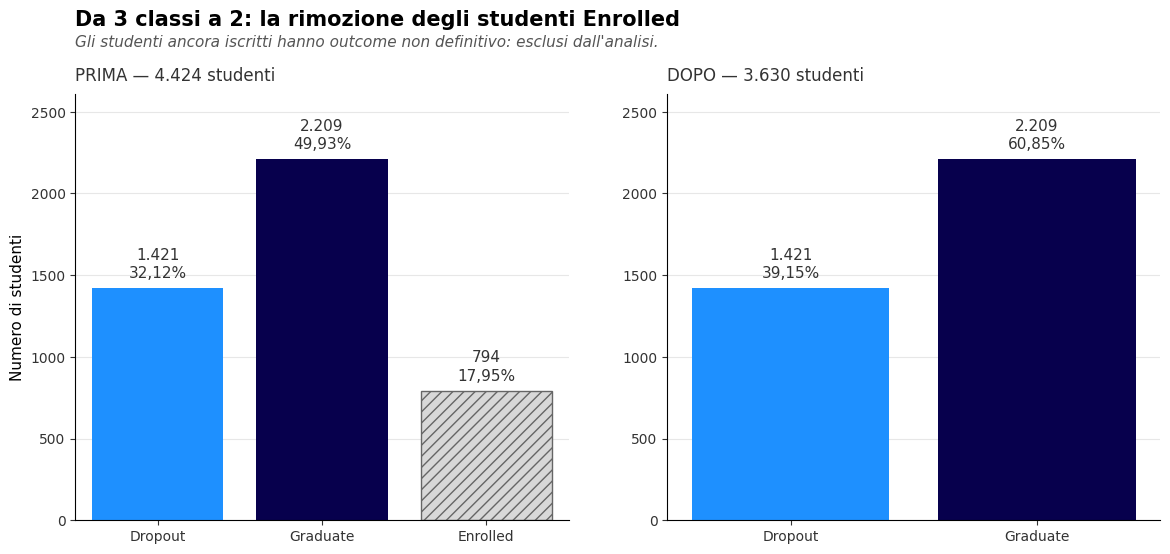

In [9]:
# ====================================================================
# Grafico comparativo PRIMA / DOPO della rimozione degli Enrolled
# ====================================================================

# === STEP A: Funzione di disegno riusabile ===

def draw_target_bars(ax, data, total, palette):
    """
    Disegna un bar chart del target su un asse, con annotazioni e stile.

    Parametri
    ---------
    ax : matplotlib.axes.Axes
        L'asse su cui disegnare.
    data : pd.DataFrame
        DataFrame con indice = nomi classi e colonna 'count'.
    total : int
        Totale di riferimento per il calcolo delle percentuali.
    palette : dict
        Mapping {nome_classe: colore_hex}.
    """
    # --- Disegno barre ---
    sns.barplot(
        x=data.index,
        y=data['count'],
        hue=data.index,
        palette=palette,
        saturation=1.0,
        edgecolor='none',
        legend=False,
        ax=ax,
    )

    # Hatching diagonale solo sulla barra Enrolled (se presente)
    for patch, label in zip(ax.patches, data.index):
        if label == 'Enrolled':
            patch.set_hatch('///')
            patch.set_edgecolor('#666666')

    # --- Annotazioni numeriche sopra le barre ---
    y_max = data['count'].max()
    text_offset = y_max * 0.02

    for patch, label in zip(ax.patches, data.index):
        count = data.loc[label, 'count']
        # Percentuale ricalcolata sul totale passato (PRIMA o DOPO)
        pct = (count / total) * 100

        x_pos = patch.get_x() + patch.get_width() / 2
        y_pos = patch.get_height() + text_offset

        # Formato numerico stile italiano: punto migliaia, virgola decimali
        count_text = f"{int(count):,}".replace(",", ".")
        pct_text = f"{pct:.2f}".replace(".", ",") + "%"

        annotation = f"{count_text}\n{pct_text}"

        ax.text(
            x_pos, y_pos, annotation,
            ha='center',
            va='bottom',
            fontsize=11,
            color='#333333',
            linespacing=1.3,
        )

    # --- Rifiniture asse ---
    ax.set_ylim(0, y_max * 1.18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_xlabel('')
    ax.tick_params(axis='both', labelsize=10, colors='#333333')


# === STEP B: Preparazione dei due dataset ===

# Palette: convenzioni del progetto (US-07) + grigio chiaro per Enrolled
class_colors = {
    'Dropout':  '#1e90ff',   # Dodger Blue
    'Graduate': '#07004d',   # Navy
    'Enrolled': '#d8d8d8',   # grigio chiaro: classe rimossa
}

# --- Dataset PRIMA: dallo snapshot iniziale ---
plot_data_before = distribution_before.drop('TOTAL').copy()
plot_data_before = plot_data_before.reindex(['Dropout', 'Graduate', 'Enrolled'])
total_before = int(distribution_before.loc['TOTAL', 'count'])

# --- Dataset DOPO: ricostruito dal df filtrato ---
# Nel df attuale Target è codificato (0=Graduate, 1=Dropout).
plot_data_after = pd.DataFrame({
    'count': [
        (df['Target'] == 1).sum(),   # Dropout
        (df['Target'] == 0).sum(),   # Graduate
    ]
}, index=['Dropout', 'Graduate'])
total_after = len(df)


# === STEP C: Figura, subplot, titoli ===

# Figura con due subplot affiancati di larghezza identica
fig, (ax_before, ax_after) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=True,
    gridspec_kw={'width_ratios': [1, 1]},   # larghezze identiche
)

# Disegno dei due grafici tramite la funzione
draw_target_bars(ax_before, plot_data_before, total_before, class_colors)
draw_target_bars(ax_after,  plot_data_after,  total_after,  class_colors)

# Label asse Y su entrambi i subplot
ax_before.set_ylabel('Numero di studenti', fontsize=11)
ax_after.set_ylabel('Numero di studenti', fontsize=11)

# Riabilita i tick label sull'asse Y del subplot di destra
# (sharey li nasconderebbe di default)
ax_after.tick_params(axis='y', labelleft=True)

# Mini-titoli sopra ciascun subplot
ax_before.set_title(
    f"PRIMA — {total_before:,} studenti".replace(",", "."),
    fontsize=12,
    color='#333333',
    loc='left',
    pad=10,
)
ax_after.set_title(
    f"DOPO — {total_after:,} studenti".replace(",", "."),
    fontsize=12,
    color='#333333',
    loc='left',
    pad=10,
)

# Titolo + sottotitolo dell'intera figura, ancorati all'asse di sinistra
axis_left = ax_before.get_position().x0

fig.text(
    axis_left, 0.961,
    'Da 3 classi a 2: la rimozione degli studenti Enrolled',
    fontsize=15,
    fontweight='bold',
    ha='left',
    va='top',
)

fig.text(
    axis_left, 0.92,
    'Gli studenti ancora iscritti hanno outcome non definitivo: '
    'esclusi dall\'analisi.',
    fontsize=11,
    fontstyle='italic',
    color='#555555',
    ha='left',
    va='top',
)

# Spazio in cima per i titoli
plt.subplots_adjust(top=0.82)

plt.show()

### 2.6 Salvataggio della figura

Salviamo il PNG in `outputs/figures/` per disporre dell'asset come
file indipendente, utilizzabile nella presentazione finale.
Le convenzioni di naming, dpi e bbox sono quelle definite in
`PROJECT_CONVENTIONS.md`.

In [10]:
# === Salvataggio della figura ===

# Path di destinazione: cartella outputs/figures/ relativa alla root del progetto
output_dir = '../outputs/figures'
output_filename = 'us02_target_distribution_before_after.png'
output_path = os.path.join(output_dir, output_filename)

# Creiamo la cartella se non esiste (idempotente: non fa nulla se c'è già)
os.makedirs(output_dir, exist_ok=True)

# Salvataggio: dpi 150 e bbox tight come da convenzioni del progetto
fig.savefig(
    output_path,
    dpi=150,
    bbox_inches='tight',
)

print(f"Figura salvata in: {output_path}")

Figura salvata in: ../outputs/figures\us02_target_distribution_before_after.png


### Risultato

Da un dataset iniziale di **4.424 studenti** ripartiti su 3 classi
(`Dropout`, `Graduate`, `Enrolled`), abbiamo escluso i **794 studenti
ancora iscritti** (17,95% del totale) e codificato il target binario
risultante. Il dataset finale conta **3.630 studenti** suddivisi in:

- **Graduate** (codificato `0`): 2.209 studenti, 60,85% del nuovo totale
- **Dropout** (codificato `1`): 1.421 studenti, 39,15% del nuovo totale

### Considerazione metodologica

L'esclusione degli studenti `Enrolled` non è una pulizia di dati
"sporchi" ma una scelta di **definizione del problema**. Gli iscritti
hanno un percorso ancora aperto: includerli avrebbe significato
trasformare la classificazione binaria in un problema multi-classe con
una classe semanticamente diversa dalle altre due — un outcome
"sospeso" accanto a due outcome conclusi. Limitare l'analisi ai casi
con outcome definitivo permette al modello di apprendere segnali
chiari e di restituire predizioni interpretabili.

La distribuzione finale presenta uno **sbilanciamento moderato**
(60,85% Graduate vs 39,15% Dropout). Non è drammatico — un modello
banale che predicesse sempre la classe maggioritaria avrebbe accuracy
del 60,85%, già "sospettoso" ma non bloccante. Va comunque tenuto
presente: in Sprint 3 dovremo usare metriche oltre l'accuracy
(F1, Precision, Recall) e considerare strategie di compensazione
(`class_weight='balanced'` nei modelli, eventuale resampling).

### Implicazioni per le US successive

- **US-03 (rinomina variabili)**: lavorerà sul dataset filtrato di
  3.630 righe, non sul dataset originale. La colonna target attualmente
  si chiama `Target` (PascalCase) e verrà ridenominata a `target` con
  il resto delle colonne
- **US-04 (controllo duplicati)**: il controllo va fatto sul dataset
  post-filtro, dove la probabilità di duplicati esatti è bassa ma il
  test resta una garanzia metodologica
- **Sprint 3 (modeling)**: lo sbilanciamento 60,85 / 39,15 va gestito
  esplicitamente. La classe positiva del problema è codificata `1`
  (Dropout): tutte le metriche di scikit-learn riferite alla classe
  positiva saranno direttamente interpretabili come "qualità della
  predizione del rischio dropout"

---

## US-03 · Rinomina delle Variabili <a id="us-03"></a>

**Responsabile**: Youssra Zarouky

### Obiettivo
In questa sezione rinominiamo tutte le colonne del dataset in `snake_case`,
rimuovendo spazi, apostrofi e caratteri speciali.
La funzione è stata estratta in `src/preprocessing.py` per riutilizzo.

In [11]:
df = rename_columns(df)

print("Colonne rinominate:")
print(df.columns.tolist())

Colonne rinominate:
['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nationality', 'mothers_qualification', 'fathers_qualification', 'mothers_occupation', 'fathers_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'cu_1st_sem_credited', 'cu_1st_sem_enrolled', 'cu_1st_sem_evaluations', 'cu_1st_sem_approved', 'cu_1st_sem_grade', 'cu_1st_sem_without_evaluations', 'cu_2nd_sem_credited', 'cu_2nd_sem_enrolled', 'cu_2nd_sem_evaluations', 'cu_2nd_sem_approved', 'cu_2nd_sem_grade', 'cu_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp', 'target']


---

## US-04 · Controllo dei Duplicati <a id="us-04"></a>

**Responsabile**: Jessica M Pucci

### Obiettivo
Verificare la presenza di righe duplicate nel dataset a valle della rimozione degli Enrolled (§ 2) e della rinomina delle variabili (§ 3), e documentare la decisione su come gestirle.

Una riga duplicata, in questo contesto, rappresenterebbe due studenti con valori identici su tutte le 37 variabili: stesso corso, stessa età, stessi voti semestrali, stessi indicatori socio-economici, stesso outcome.

In [12]:
# Calcolo delle metriche di base
n_total = len(df)
n_duplicates = df.duplicated().sum()  # True dalla 2a occorrenza in poi
pct_duplicates = (n_duplicates / n_total) * 100

# Output leggibile
print(f"Righe totali:    {n_total}")
print(f"Righe duplicate: {n_duplicates} ({pct_duplicates:.2f}%)")

# Rimozione condizionale: agiamo solo se ci sono effettivamente duplicati.
# Rende esplicito l'intento e produce un output chiaro in entrambi i casi.
if n_duplicates > 0:
    # reset_index(drop=True) evita indici "bucati" dopo la rimozione
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Righe dopo rimozione: {len(df)}")
else:
    print("Nessuna rimozione necessaria.")

Righe totali:    3630
Righe duplicate: 0 (0.00%)
Nessuna rimozione necessaria.


### Risultato
Il dataset non contiene righe duplicate (**0 su 3.630 righe**, 0,00%).

### Considerazione
Il risultato è coerente con le aspettative. Le variabili sono 36 e la probabilità che due studenti coincidano esattamente su tutte queste dimensioni è trascurabile, salvo errori di inserimento. Inoltre il dataset UCI è già stato preprocessato dagli autori prima della pubblicazione, quindi eventuali duplicati grossolani sarebbero già stati gestiti a monte.

Va comunque sottolineato che il controllo era necessario: la presenza di duplicati avrebbe compromesso la fase di train/test split nello Sprint 3, dove lo stesso individuo rischierebbe di finire in entrambi i set causando **data leakage** — il modello "vedrebbe" in fase di test dati già visti in training, sovrastimando le sue performance.

### Decisione
Nessuna rimozione necessaria. Il dataset mantiene le sue **3.630** righe e si procede con US-05 (Analisi dei Missing Values) sul dataset invariato.

---

## US-05 · Analisi dei Missing Values <a id="us-05"></a>

**Responsabile**: Youssra Zarouky

### Obiettivo
Verificare la presenza di valori mancanti su tutte le colonne e documentare la strategia scelta per gestirli.

In [13]:
analyze_missing_values(df)

Colonne con valori mancanti: 0 su 37

                                missing  percentuale
marital_status                        0          0.0
application_mode                      0          0.0
application_order                     0          0.0
course                                0          0.0
daytime_evening_attendance            0          0.0
previous_qualification                0          0.0
previous_qualification_grade          0          0.0
nationality                           0          0.0
mothers_qualification                 0          0.0
fathers_qualification                 0          0.0
mothers_occupation                    0          0.0
fathers_occupation                    0          0.0
admission_grade                       0          0.0
displaced                             0          0.0
educational_special_needs             0          0.0
debtor                                0          0.0
tuition_fees_up_to_date               0          0.0
gender  

,missing,percentuale
marital_status,0,0.0
application_mode,0,0.0
application_order,0,0.0
course,0,0.0
daytime_evening_attendance,0,0.0
previous_qualification,0,0.0
previous_qualification_grade,0,0.0
nationality,0,0.0
mothers_qualification,0,0.0
fathers_qualification,0,0.0


### Risultato
Il dataset non contiene valori mancanti (**0 su 37 colonne**).

### Considerazione
Il risultato è atteso: il dataset UCI è stato già preprocessato dagli autori prima della pubblicazione. La verifica era comunque necessaria per garantire l'integrità dei dati prima di procedere con le fasi successive.

### Decisione
Nessuna imputazione necessaria. Il dataset procede invariato verso US-06 (Analisi Descrittiva).

Se fossero stati rilevati valori mancanti, la strategia sarebbe stata:
- **Variabili numeriche continue** (voti, età, tassi macroeconomici): imputazione con la **mediana**, più robusta agli outlier rispetto alla media
- **Variabili categoriche** (codici corso, stato civile, qualifica genitori): imputazione con la **moda**, cioè la categoria più frequente

---

## US-06 · Analisi Descrittiva delle Variabili Numeriche <a id="us-06"></a>

**Responsabile**: Jessica M Pucci

### Obiettivo
Calcolare le principali statistiche descrittive (media, mediana,
deviazione standard, minimo, massimo) sulle variabili numeriche del
dataset e verificare che i loro valori ricadano nei range plausibili
attesi, sulla base del dominio (sistema di voti portoghese, età
all'iscrizione, indicatori macroeconomici). Eventuali anomalie
strutturali — non statistiche — vengono segnalate qui per essere
approfondite in fase di analisi outlier (US-08).

### Approccio
1. **Premessa metodologica**: definizione operativa di "variabile numerica"
   ai fini di questa sezione, con esclusione delle categoriche encoded
2. **Statistiche descrittive**: tabella con media, mediana, deviazione
   standard, minimo, massimo per ciascuna variabile selezionata
3. **Range plausibility check**: verifica che i valori osservati ricadano
   entro i range attesi dal dominio (voti, età, tassi macroeconomici)

### 6.1 Premessa metodologica

Dopo le trasformazioni di US-01–US-05, il dataset contiene 37 colonne
tutte di tipo numerico (`int64` o `float64`). Tuttavia non tutte sono
realmente numeriche dal punto di vista statistico: molte di esse sono
**variabili categoriche encoded** — codici arbitrari assegnati per
identificare modalità (es. `course` come codice del corso di laurea,
`gender` come `0`/`1`, `marital_status` come codice dello stato civile).

Calcolare media, deviazione standard o minimo/massimo su questi codici
è privo di significato interpretativo. Ai fini della US-06 restringiamo
quindi l'analisi alle **18 variabili realmente numeriche** del dataset,
che coprono quattro dimensioni del problema:

- **Caratteristiche all'iscrizione** (3): voto della qualifica
  precedente, voto di ammissione, età all'iscrizione
- **Performance accademica al 1° semestre** (6): conteggi di unità
  curriculari (riconosciute per crediti, iscritte, valutate, approvate, senza
  valutazioni) e voto medio
- **Performance accademica al 2° semestre** (6): stessa struttura del
  1° semestre
- **Indicatori macroeconomici** (3): tasso di disoccupazione, tasso di
  inflazione, PIL

Il `target` è escluso dalla descrittiva: è la label binaria del
problema, non una feature.

### 6.2 Statistiche descrittive

Definiamo la lista delle 18 variabili numeriche selezionate e
verifichiamo la loro presenza nel `df`. La verifica protegge da
disallineamenti rispetto alla rinomina di US-03.

In [14]:
# Lista delle variabili numeriche selezionate (vedi premessa 6.1)
numeric_features = [
    'previous_qualification_grade',
    'admission_grade',
    'age_at_enrollment',
    'cu_1st_sem_credited',
    'cu_1st_sem_enrolled',
    'cu_1st_sem_evaluations',
    'cu_1st_sem_approved',
    'cu_1st_sem_grade',
    'cu_1st_sem_without_evaluations',
    'cu_2nd_sem_credited',
    'cu_2nd_sem_enrolled',
    'cu_2nd_sem_evaluations',
    'cu_2nd_sem_approved',
    'cu_2nd_sem_grade',
    'cu_2nd_sem_without_evaluations',
    'unemployment_rate',
    'inflation_rate',
    'gdp',
]

# Verifica presenza nel df
missing = [c for c in numeric_features if c not in df.columns]
if missing:
    print(f"Colonne mancanti: {missing}")
else:
    print(f"Tutte le {len(numeric_features)} colonne sono presenti nel df.")

Tutte le 18 colonne sono presenti nel df.


Calcoliamo media, mediana, deviazione standard, minimo e massimo
sulle 18 variabili. Arrotondamento a 1 decimale per le variabili a
larga scala (voti e conteggi) e a 2 decimali per gli indicatori
macroeconomici, che hanno valori piccoli e perderebbero informazione.

In [15]:
# Tabella descrittiva: mean, median, std, min, max
desc = df[numeric_features].agg(['mean', 'median', 'std', 'min', 'max']).T

# Arrotondamento differenziale per leggibilità
macro = ['unemployment_rate', 'inflation_rate', 'gdp']
non_macro = [c for c in desc.index if c not in macro]
desc.loc[non_macro] = desc.loc[non_macro].round(1)
desc.loc[macro] = desc.loc[macro].round(2)

desc

,mean,median,std,min,max
previous_qualification_grade,132.90,133.10,13.20,95.00,190.00
admission_grade,127.30,126.50,14.60,95.00,190.00
age_at_enrollment,23.50,20.00,7.80,17.00,70.00
cu_1st_sem_credited,0.80,0.00,2.50,0.00,20.00
cu_1st_sem_enrolled,6.30,6.00,2.60,0.00,26.00
cu_1st_sem_evaluations,8.10,8.00,4.30,0.00,45.00
cu_1st_sem_approved,4.80,5.00,3.20,0.00,26.00
cu_1st_sem_grade,10.50,12.30,5.10,0.00,18.90
cu_1st_sem_without_evaluations,0.10,0.00,0.70,0.00,12.00
cu_2nd_sem_credited,0.60,0.00,2.00,0.00,19.00


### 6.2.1 Simmetria delle distribuzioni

Confrontiamo media e mediana per ciascuna variabile per ottenere
un primo indicatore di asimmetria della distribuzione: in una
distribuzione simmetrica i due valori coincidono, mentre uno
scostamento sistematico segnala una coda. Usiamo lo scarto normalizzato
`(mean - median) / std` per rendere il confronto comparabile tra
variabili a scale diverse. Soglia di simmetria: `|scarto| < 0.1`.

In [16]:
# Scarto normalizzato mean-median per ogni variabile numerica
skew_hint = pd.DataFrame({
    'mean': df[numeric_features].mean(),
    'median': df[numeric_features].median(),
    'std': df[numeric_features].std(),
})
skew_hint['scarto_norm'] = (skew_hint['mean'] - skew_hint['median']) / skew_hint['std']

# Classificazione: simmetrica / asimmetrica destra / asimmetrica sinistra
def classify(s):
    if abs(s) < 0.1:
        return 'simmetrica'
    return 'asimmetrica destra' if s > 0 else 'asimmetrica sinistra'

skew_hint['forma'] = skew_hint['scarto_norm'].apply(classify)
skew_hint = skew_hint[['mean', 'median', 'scarto_norm', 'forma']].round(2)
skew_hint

,mean,median,scarto_norm,forma
previous_qualification_grade,132.92,133.10,-0.01,simmetrica
admission_grade,127.29,126.50,0.05,simmetrica
age_at_enrollment,23.46,20.00,0.44,asimmetrica destra
cu_1st_sem_credited,0.75,0.00,0.30,asimmetrica destra
cu_1st_sem_enrolled,6.34,6.00,0.13,asimmetrica destra
cu_1st_sem_evaluations,8.07,8.00,0.02,simmetrica
cu_1st_sem_approved,4.79,5.00,-0.06,simmetrica
cu_1st_sem_grade,10.53,12.34,-0.36,asimmetrica sinistra
cu_1st_sem_without_evaluations,0.13,0.00,0.19,asimmetrica destra
cu_2nd_sem_credited,0.58,0.00,0.29,asimmetrica destra


### 6.3 Range plausibility check

Verifichiamo che i valori osservati ricadano entro i range di
possibilità definiti dal dominio. L'obiettivo non è identificare
outlier statistici (rinviati a US-08) ma intercettare valori
strutturalmente impossibili: età negative, voti fuori scala,
tassi macroeconomici implausibili.

In [17]:
# Range possibili per ciascuna variabile (estremi inclusi)
expected_ranges = {
    'previous_qualification_grade': (0, 200),
    'admission_grade': (0, 200),
    'age_at_enrollment': (17, 90),
    'cu_1st_sem_credited': (0, 20),
    'cu_1st_sem_enrolled': (0, 15),
    'cu_1st_sem_evaluations': (0, 45),
    'cu_1st_sem_approved': (0, 15),
    'cu_1st_sem_grade': (0, 20),
    'cu_1st_sem_without_evaluations': (0, 15),
    'cu_2nd_sem_credited': (0, 20),
    'cu_2nd_sem_enrolled': (0, 15),
    'cu_2nd_sem_evaluations': (0, 45),
    'cu_2nd_sem_approved': (0, 15),
    'cu_2nd_sem_grade': (0, 20),
    'cu_2nd_sem_without_evaluations': (0, 15),
    'unemployment_rate': (5, 20),
    'inflation_rate': (-2, 5),
    'gdp': (-5, 5),
}

# Check: confronta min/max osservati con i range attesi
violations = []
for col, (low, high) in expected_ranges.items():
    obs_min, obs_max = df[col].min(), df[col].max()
    if obs_min < low or obs_max > high:
        violations.append((col, obs_min, obs_max, low, high))

if violations:
    print(f"Trovate {len(violations)} variabili fuori range:")
    for col, omin, omax, low, high in violations:
        print(f"  - {col}: osservato [{omin}, {omax}], atteso [{low}, {high}]")
else:
    print(f"Nessuna anomalia: tutte le {len(expected_ranges)} variabili rientrano nei range attesi.")

Trovate 4 variabili fuori range:
  - cu_1st_sem_enrolled: osservato [0, 26], atteso [0, 15]
  - cu_1st_sem_approved: osservato [0, 26], atteso [0, 15]
  - cu_2nd_sem_enrolled: osservato [0, 23], atteso [0, 15]
  - cu_2nd_sem_approved: osservato [0, 20], atteso [0, 15]


### Risultato

Sul dataset di **3.630 studenti** abbiamo calcolato media, mediana,
deviazione standard, minimo e massimo per le **18 variabili numeriche**
selezionate, raggruppate in quattro dimensioni: caratteristiche
all'iscrizione (3), performance al 1° semestre (6), performance al 2°
semestre (6), indicatori macroeconomici (3).

Il confronto media-mediana ha classificato come **simmetriche** 6
delle 18 variabili e come **asimmetriche** le restanti 12 (8 destra,
4 sinistra). I casi più rilevanti:

- `age_at_enrollment`: asimmetria destra (scarto normalizzato 0,44),
  mediana 20 anni, media 23,5 — coda di studenti maturi
- `cu_1st_sem_grade` e `cu_2nd_sem_grade`: asimmetria sinistra forte
  (-0,36 e -0,42), mediana ~12,3 contro media ~10 — coerente con una
  presenza significativa di studenti con voto 0 (corsi non superati)
  che tira la media verso il basso
- `cu_*_credited`: asimmetria destra con mediana 0, indicando che la
  maggioranza degli studenti non ha riconoscimenti di crediti pregressi

Il range plausibility check ha intercettato 4 colonne con valori oltre
il tetto atteso, tutte sui conteggi di unità curriculari:

- `cu_1st_sem_enrolled`: massimo osservato 26 (atteso ≤ 15)
- `cu_1st_sem_approved`: massimo osservato 26 (atteso ≤ 15)
- `cu_2nd_sem_enrolled`: massimo osservato 23 (atteso ≤ 15)
- `cu_2nd_sem_approved`: massimo osservato 20 (atteso ≤ 15)

Un'esplorazione mirata ha rivelato 55 studenti (1,52% del totale) con
carico didattico al 1° semestre superiore a 15 unità curriculari, con
pattern ricorrenti (`18/13`, `17/17`, `21/19`) che suggeriscono
ordinamenti didattici specifici piuttosto che errori di data entry.

### Considerazione metodologica

Il confronto media-mediana qui adottato è un **indicatore esplorativo**
di asimmetria, non una misura formale di skewness: classifica le
variabili per scostamento normalizzato $`(mean - median) / std`$ con
soglia `0,1`, sufficiente a orientare le scelte di visualizzazione e
trasformazione successive ma non a sostituire test statistici dedicati.

Il range plausibility check verifica l'**impossibilità strutturale**
dei valori (età negative, voti fuori scala, carichi didattici fisicamente
improponibili), non la loro rarità statistica. È un controllo di dominio,
non di distribuzione: serve a intercettare errori di data entry o
disallineamenti di scala, non a identificare outlier.

La tipizzazione "variabile numerica" usata in questa sezione include
solo le 18 colonne realmente numeriche del dataset, escludendo le 18
variabili categoriche encoded che condividono il `dtype` numerico ma
rappresentano codici arbitrari di modalità.

### Implicazioni

La distribuzione presumibilmente bimodale dei voti semestrali (massa
di zeri da corsi non superati + corpo centrale attorno al voto pieno)
è il segnale più rilevante per **US-07**, dove andrà visualizzata con
istogrammi separati per target. Anche la coda destra di
`age_at_enrollment` merita attenzione visiva, in particolare per
verificare se la popolazione "studenti maturi" si distribuisce in modo
omogeneo tra Dropout e Graduate.

I 55 studenti con carico didattico anomalo non vengono rimossi né
modificati in questa sede: rappresentano un fenomeno strutturale
(1,52% del dataset, con regolarità di pattern) che richiede una verifica
statistica più fine, rinviata all'analisi degli outlier nello Sprint 2.

Le restanti 14 variabili numeriche rispettano i range attesi e, insieme
alle 18 categoriche, sono pronte per le fasi successive di analisi
esplorativa e modellazione (Sprint 2).

---

## Export del Dataset Processato <a id="export"></a>

Salviamo il DataFrame finale `df` in `data/processed/data_clean.csv`
per renderlo disponibile ai notebook successivi (analisi esplorativa
e modellazione) senza dover ri-eseguire l'intera pipeline di
preparazione dello Sprint 1.

In [18]:
# Path relativo alla cartella notebooks/
output_path = Path('../data/processed/data_clean.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(output_path, index=False)
print(f"Dataset esportato: {output_path}")
print(f"Dimensioni: {df.shape[0]} righe x {df.shape[1]} colonne")

Dataset esportato: ..\data\processed\data_clean.csv
Dimensioni: 3630 righe x 37 colonne


---